In [50]:
import sys
from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers import Liu2025

z1 paper ndens=81.9 1 / deg2, sum of n 82.01 1 / deg2, int of dndz 82.01 1 / deg2
z2 paper ndens=148.1 1 / deg2, sum of n 148.19 1 / deg2, int of dndz 148.19 1 / deg2
z3 paper ndens=162.4 1 / deg2, sum of n 162.57 1 / deg2, int of dndz 162.57 1 / deg2
z4 paper ndens=148.3 1 / deg2, sum of n 148.49 1 / deg2, int of dndz 148.49 1 / deg2


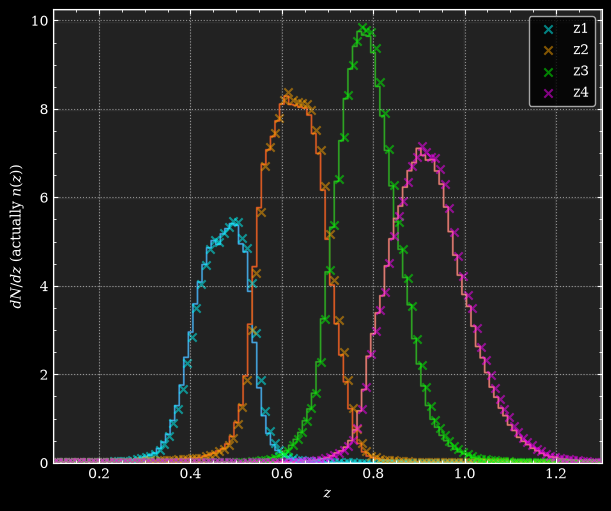

In [56]:
importlib.reload(Liu2025)
fig, ax = Liu2025.Fig2().full()

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'orange', 'lime', 'magenta']):
    L25 = Liu2025.TargetData(zbin=zbin)
    z, n_z = L25.n_z(dz = 0.01)
    ax.scatter(z, n_z, alpha=0.5, marker='x', c=color, label=f'{L25.zbin}')

    z, dndz = L25.dndz(dz = 0.01)
    print(f'{L25.zbin} paper ndens={L25.nGal}, sum of n {np.sum(n_z):.2f}, int of dndz {np.trapezoid(dndz, z):.2f}')

ax.legend()
plt.show()

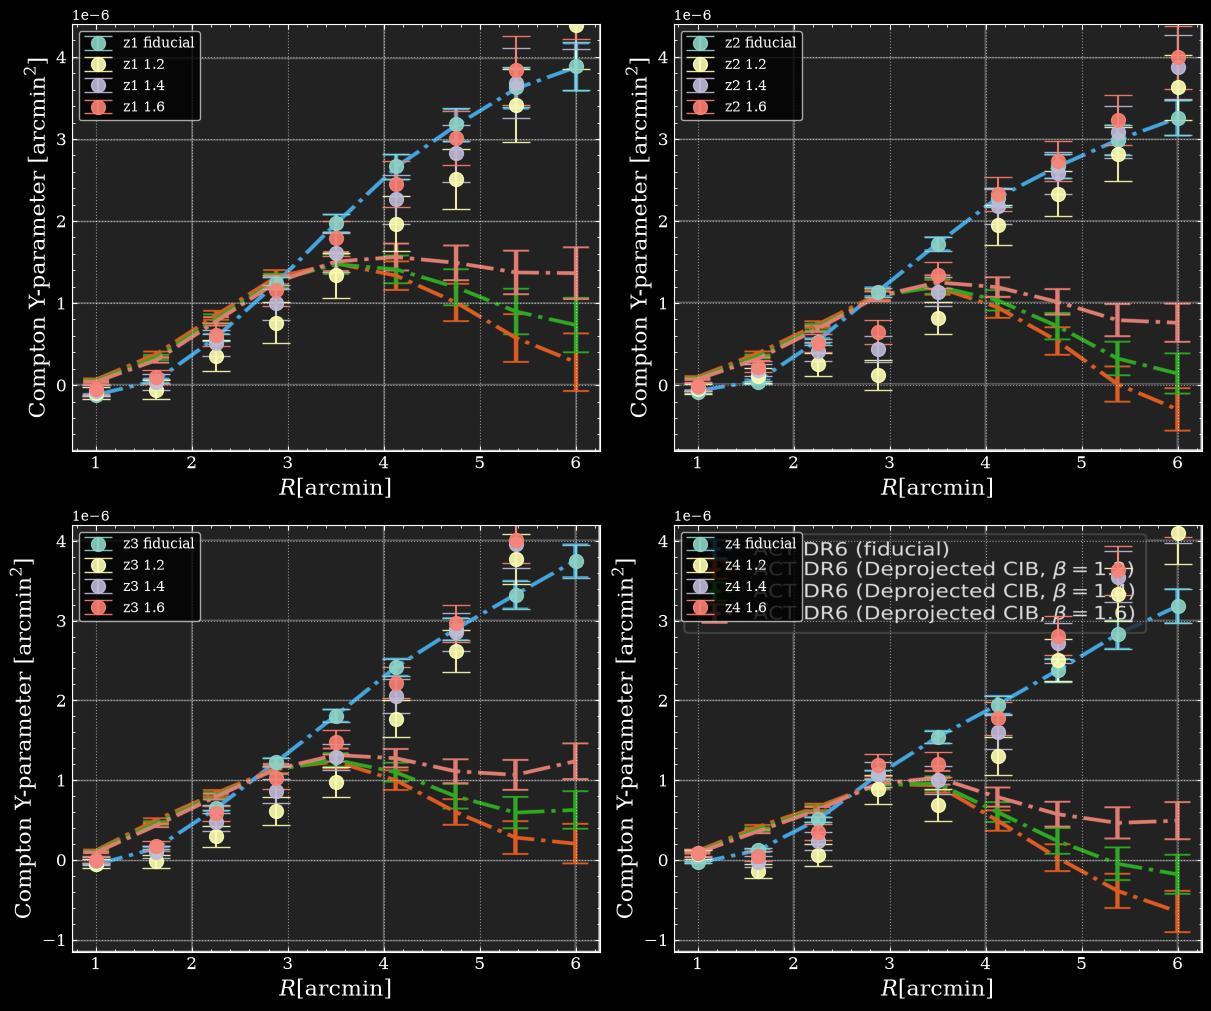

In [52]:
importlib.reload(Liu2025)
fig, axs = Liu2025.Fig3().full()

for zbin, ax in zip(['z1', 'z2', 'z3', 'z4'], axs.flatten()):
    for beta in Liu2025.Measurement.subs['Beta']:
        L25 = Liu2025.Measurement(zbin=zbin, ACTDR='DR6', dp='beta', TCIB='10.7', Beta=beta)
        ax.errorbar(L25.R, L25.y_data, L25.y_err, ls='',alpha=0.9,marker='o', markersize=10,capsize=10,label=f'{zbin} {beta}')
    ax.legend()
plt.show()

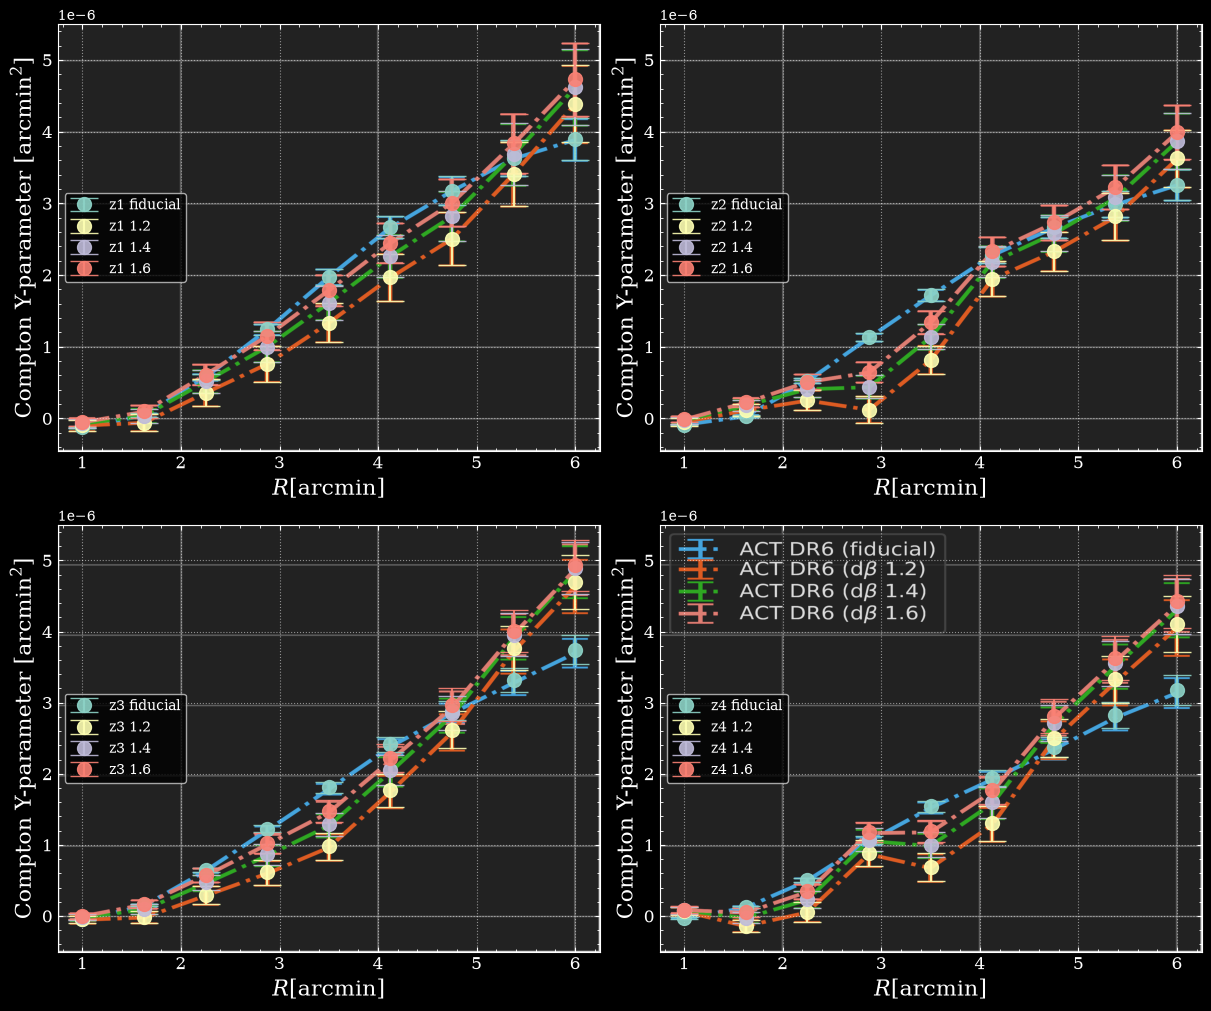

In [53]:
importlib.reload(Liu2025)
fig, axs = Liu2025.Fig4().full()

for zbin, ax in zip(['z1', 'z2', 'z3', 'z4'], axs.flatten()):
    for beta in Liu2025.Measurement.subs['Beta']:
        L25 = Liu2025.Measurement(zbin=zbin, ACTDR='DR6', dp='dBeta', TCIB='10.7', Beta=beta)
        ax.errorbar(L25.R, L25.y_data, L25.y_err, ls='',alpha=0.9,marker='o', markersize=10,capsize=10,label=f'{zbin} {beta}')
    ax.legend(loc='center left')
plt.show()